In [ ]:
import numpy as np

In [ ]:
path='/content/drive/MyDrive/preprocessed_data/'


In [ ]:
X_train = np.load(path + 'X_train.npy')
y_train = np.load(path + 'y_train.npy')
X_test = np.load(path + 'X_test.npy')
y_test = np.load(path + 'y_test.npy')

In [ ]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.restoration import denoise_nl_means, estimate_sigma
from skimage import img_as_float
from tqdm import tqdm

SEED = 42

raw_data_folder = "/content/drive/MyDrive/preprocessed_data"
processed_data_folder = "/content/drive/MyDrive/preprocessed_clahe"
plots_folder = "/content/drive/MyDrive/preprocessed_clahe_plots"

clahe_clip_limit = 2.0
clahe_grid_size = (8, 8)
noise_reduction_strength = 1.15
patch_comparison_size = 5
patch_search_distance = 3

np.random.seed(SEED)
os.makedirs(processed_data_folder, exist_ok=True)
os.makedirs(plots_folder, exist_ok=True)


def save_preprocessing_plot(before_img, after_img, index, split):

    save_path = os.path.join(plots_folder, f"{split}image{index}.png")

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(before_img)
    plt.title("Before")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(after_img)
    plt.title("After (Denoise + CLAHE) ")
    plt.axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()


def clean_and_enhance_images(images, description="Processing", split="Train"):
    print(f'Cleaning and enhancing {len(images)} images : ')
    processed_images = np.empty_like(images, dtype=np.float32)

    contrast_enhancer = cv2.createCLAHE(
        clipLimit=clahe_clip_limit,
        tileGridSize=clahe_grid_size
    )

    for i in tqdm(range(images.shape[0]), desc=description):
        current_image = images[i]

        image_as_float = img_as_float(current_image)
        estimated_noise = np.mean(estimate_sigma(image_as_float, channel_axis=-1))

        cleaned_image = denoise_nl_means(
            image_as_float,
            h=noise_reduction_strength * estimated_noise,
            fast_mode=True,
            patch_size=patch_comparison_size,
            patch_distance=patch_search_distance,
            channel_axis=-1
        )

        image_8bit = (cleaned_image * 255).astype(np.uint8)

        lab_image = cv2.cvtColor(image_8bit, cv2.COLOR_RGB2LAB)
        lightness, color_a, color_b = cv2.split(lab_image)

        enhanced_lightness = contrast_enhancer.apply(lightness)

        enhanced_lab = cv2.merge((enhanced_lightness, color_a, color_b))
        final_image = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2RGB)

        processed_images[i] = final_image.astype(np.float32) / 255.0

        if i % 50 == 0:
            save_preprocessing_plot(current_image, processed_images[i], i, split)

    return processed_images


def main():
    print("Processing : ")

    try:
        train_images = np.load(os.path.join(raw_data_folder, 'X_train.npy'))
        train_labels = np.load(os.path.join(raw_data_folder, 'y_train.npy'))
    except Exception as error:
        print("Training data not found:", error)
        train_images, train_labels = None, None

    try:
        test_images = np.load(os.path.join(raw_data_folder, 'X_test.npy'))
        test_labels = np.load(os.path.join(raw_data_folder, 'y_test.npy'))
    except Exception as error:
        print("Test data not found:", error)
        test_images, test_labels = None, None

    if train_images is not None:
        processed_train = clean_and_enhance_images(train_images, "Train", split="Train")
        np.save(os.path.join(processed_data_folder, 'X_train_processed.npy'), processed_train)
        np.save(os.path.join(processed_data_folder, 'y_train.npy'), train_labels)

    if test_images is not None:
        processed_test = clean_and_enhance_images(test_images, "Test", split="Test")
        np.save(os.path.join(processed_data_folder, 'X_test_processed.npy'), processed_test)
        np.save(os.path.join(processed_data_folder, 'y_test.npy'), test_labels)

    print("\n PREPROCESSING COMPLETE!\n")


if __name__ == "__main__":
    main()

Processing : 
Cleaning and enhancing 2400 images : 


Train: 100%|██████████| 2400/2400 [02:06<00:00, 18.93it/s]


Cleaning and enhancing 600 images : 


Test: 100%|██████████| 600/600 [00:48<00:00, 12.28it/s]



 PREPROCESSING COMPLETE!



In [ ]:
import os
import numpy as np

processed_data_folder = "/content/drive/MyDrive/preprocessed_clahe"
sample_data_folder = "/content/drive/MyDrive/sample_processed"

number_of_train_samples = 200
number_of_test_samples = 50

os.makedirs(sample_data_folder, exist_ok=True)

print("CREATING SAMPLE DATASET FROM PROCESSED DATA")

train_images = np.load(os.path.join(processed_data_folder, 'X_train_processed.npy'))
train_labels = np.load(os.path.join(processed_data_folder, 'y_train.npy'))

test_images = np.load(os.path.join(processed_data_folder, 'X_test_processed.npy'))
test_labels = np.load(os.path.join(processed_data_folder, 'y_test.npy'))

np.save(os.path.join(sample_data_folder, 'X_train_sample.npy'), train_images[:number_of_train_samples])
np.save(os.path.join(sample_data_folder, 'y_train_sample.npy'), train_labels[:number_of_train_samples])

np.save(os.path.join(sample_data_folder, 'X_test_sample.npy'), test_images[:number_of_test_samples])
np.save(os.path.join(sample_data_folder, 'y_test_sample.npy'), test_labels[:number_of_test_samples])

print(" SAMPLE DATASET CREATED")

CREATING SAMPLE DATASET FROM PROCESSED DATA
 SAMPLE DATASET CREATED


In [ ]:

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50V2, EfficientNetB0

def build_model(input_shape=(224, 224, 3), backbone='ResNet50V2', freeze_backbone=True, head_dropout=0.5, dense_units=256, use_batch_norm=True, compile_model=True):


    # STEP 1: Load the pre-trained backbone
    print("Loading {0} backbone...".format(backbone))

    if backbone == 'ResNet50V2':
        base_model = ResNet50V2(include_top=False, weights='imagenet', input_shape=input_shape)
    elif backbone == 'EfficientNetB0':
        base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=input_shape)
    else:
        raise ValueError("Unsupported backbone: {0}. Use 'ResNet50V2' or 'EfficientNetB0'".format(backbone))

    # STEP 2: Freeze the backbone
    if freeze_backbone:
        base_model.trainable = False
        print("Backbone frozen (weights won't change during training)")
    else:
        base_model.trainable = True
        print("Backbone unfrozen (will be fine-tuned)")

    # STEP 3: Build the classification head for brain cancer detection
    print("Building classification head for brain cancer detection...")

    # Create the input layer
    inputs = keras.Input(shape=input_shape)

    # Pass through the backbone
    x = base_model(inputs, training=False)

    # Add our custom layers on top
    x = layers.GlobalAveragePooling2D()(x)

    # Dense layer with optional Batch Normalization
    x = layers.Dense(dense_units)(x)
    if use_batch_norm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Dropout for regularization
    x = layers.Dropout(head_dropout)(x)

    # Final output layer (sigmoid for binary classification: tumor/no tumor)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    # STEP 4: Create the complete model
    model = keras.Model(inputs=inputs, outputs=outputs, name='{0}_BrainCancer'.format(backbone))

    # STEP 5: Compile the model
    if compile_model:
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=['accuracy', keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')]
        )

    print("Brain cancer detection model built successfully!")
    print("   - Backbone: {0}".format(backbone))
    print("   - Trainable parameters: {0:,}".format(model.count_params()))

    return model

# TEST FUNCTION
if __name__ == "__main__":
    print("=" * 60)
    print("TESTING BRAIN CANCER DETECTION MODEL BUILDER")
    print("=" * 60)

    # Test with ResNet50V2
    print("\n1. Building brain cancer detection model with ResNet50V2...")
    model_resnet = build_model(backbone='ResNet50V2', freeze_backbone=True, head_dropout=0.5, dense_units=256)

    # Check input/output shapes
    print("\n   Input shape: {0}".format(model_resnet.input_shape))
    print("   Output shape: {0}".format(model_resnet.output_shape))

    print("\n" + "=" * 60)
    print("ALL TESTS PASSED!")
    print("=" * 60)

TESTING BRAIN CANCER DETECTION MODEL BUILDER

1. Building brain cancer detection model with ResNet50V2...
Loading ResNet50V2 backbone...
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Backbone frozen (weights won't change during training)
Building classification head for brain cancer detection...
Brain cancer detection model built successfully!
   - Backbone: ResNet50V2
   - Trainable parameters: 24,090,625

   Input shape: (None, 224, 224, 3)
   Output shape: (None, 1)

ALL TESTS PASSED!


Train shape: (200, 224, 224, 3), Test shape: (50, 224, 224, 3)
Class weights: {0: np.float64(0.9803921568627451), 1: np.float64(1.0204081632653061)}
DATA AUGMENTATION FOR TRAINING
LOADING SAMPLE DATA FOR TRAINING

[1/3] Loading TRAIN samples (will be augmented)
   Loaded 200 train samples

[2/3] Loading TEST samples (NO augmentation)
   Loaded 50 test samples

[3/3] Creating augmented TRAIN dataset
  Enabled: flip_horizontal, rotation, zoom, contrast, brightness
 DATASETS READY!
  Train: 200 samples (augmented)
  Test:  50 samples (no augmentation)

 Ready for model training:
   train_dataset (augmented) → use in model.fit()
   test_dataset (clean) → use in model.evaluate()

 Visualizing augmentation examples


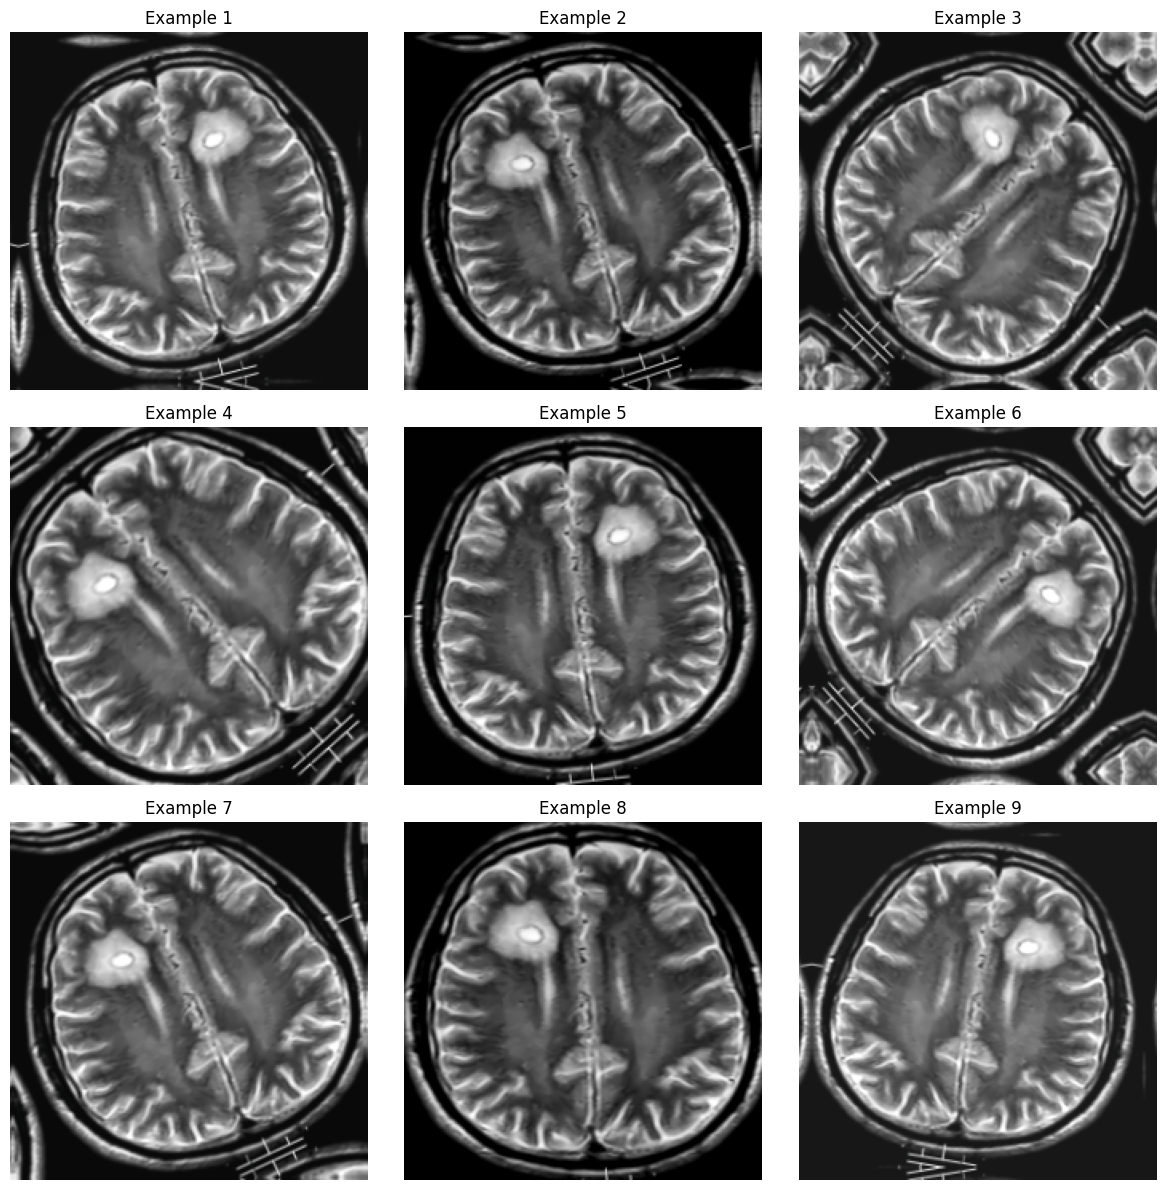


 Saved visualization: augmentation_examples.png

STARTING BASELINE EXPERIMENTS

Running → baseline_lr_1e-3 | LR: 0.001 | Batch: 32
Loading ResNet50V2 backbone...
Backbone frozen (weights won't change during training)
Building classification head for brain cancer detection...
Brain cancer detection model built successfully!
   - Backbone: ResNet50V2
   - Trainable parameters: 24,090,625
Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6172 - loss: 0.7360 - precision: 0.6392 - recall: 0.5718

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_auc` which is not available. Available metrics are: accuracy,loss,precision,recall,val_accuracy,val_loss,val_precision,val_recall
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:302: UserWarning: Can save best model only with val_auc available.
  if self._should_save_model(epoch, batch, logs, filepath):


7/7 ━━━━━━━━━━━━━━━━━━━━ 62s 7s/step - accuracy: 0.6263 - loss: 0.7233 - precision: 0.6474 - recall: 0.5794 - val_accuracy: 0.8200 - val_loss: 0.4283 - val_precision: 0.9583 - val_recall: 0.7419 - learning_rate: 0.0010
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 46s 6s/step - accuracy: 0.7989 - loss: 0.4105 - precision: 0.8634 - recall: 0.6934 - val_accuracy: 0.8800 - val_loss: 0.3325 - val_precision: 0.8788 - val_recall: 0.9355 - learning_rate: 0.0010
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 46s 7s/step - accuracy: 0.8829 - loss: 0.3187 - precision: 0.9461 - recall: 0.8245 - val_accuracy: 0.8800 - val_loss: 0.3757 - val_precision: 0.8571 - val_recall: 0.9677 - learning_rate: 0.0010
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 46s 7s/step - accuracy: 0.9108 - loss: 0.2441 - precision: 0.8889 - recall: 0.9184 - val_accuracy: 0.8200 - val_loss: 0.4504 - val_precision: 0.7895 - val_recall: 0.9677 - learning_rate: 0.0010
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 82s 7s/step - accuracy: 0.8449 - loss: 0.3435 - precisi

In [ ]:
# CELL: FULL TRAINING PIPELINE WITH YOUR AUGMENTATION (PERFECT INTEGRATION)

import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import os
import json
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.metrics import Precision, Recall # Ensure these are imported


# 1. LOAD YOUR DATA (from previous cell)

# Load the sample data generated in the previous step
sample_data_folder = "/content/drive/MyDrive/sample_processed"

X_train_sample = np.load(os.path.join(sample_data_folder, 'X_train_sample.npy'))
y_train_sample = np.load(os.path.join(sample_data_folder, 'y_train_sample.npy'))
X_test_sample = np.load(os.path.join(sample_data_folder, 'X_test_sample.npy'))
y_test_sample = np.load(os.path.join(sample_data_folder, 'y_test_sample.npy'))

print(f"Train shape: {X_train_sample.shape}, Test shape: {X_test_sample.shape}")




class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_sample),
    y=y_train_sample.ravel()
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class weights:", class_weight_dict)




augmentation_settings = {
    "flip_horizontal": True,
    "rotation": True,
    "zoom": True,
    "contrast": True,
    "brightness": True,
}

rotation_range = 0.15
zoom_range = 0.1
contrast_range = 0.1
brightness_delta = 0.1


def build_augmentation_pipeline(settings=None):
    if settings is None:
        settings = augmentation_settings

    augmentation_layers = []

    if settings.get('flip_horizontal', False):
        augmentation_layers.append(layers.RandomFlip("horizontal"))

    if settings.get('rotation', False):
        augmentation_layers.append(layers.RandomRotation(rotation_range))

    if settings.get('zoom', False):
        augmentation_layers.append(layers.RandomZoom(zoom_range))

    if settings.get('contrast', False):
        augmentation_layers.append(layers.RandomContrast(contrast_range))

    if settings.get('brightness', False):
        augmentation_layers.append(
            layers.Lambda(
                lambda x: tf.image.random_brightness(x, max_delta=brightness_delta)
            )
        )

    if not augmentation_layers:
        augmentation_layers.append(layers.Lambda(lambda x: x))

    return keras.Sequential(augmentation_layers, name="data_augmentation")


def load_and_augment_train_data(batch_size=32, shuffle=True, seed=42):
    print("LOADING SAMPLE DATA FOR TRAINING")


    print("\n[1/3] Loading TRAIN samples (will be augmented)")
    train_images = np.load(os.path.join(sample_data_folder, 'X_train_sample.npy'))
    train_labels = np.load(os.path.join(sample_data_folder, 'y_train_sample.npy'))
    print(f"   Loaded {len(train_images)} train samples")

    print("\n[2/3] Loading TEST samples (NO augmentation)")
    test_images = np.load(os.path.join(sample_data_folder, 'X_test_sample.npy'))
    test_labels = np.load(os.path.join(sample_data_folder, 'y_test_sample.npy'))
    print(f"   Loaded {len(test_images)} test samples")

    print("\n[3/3] Creating augmented TRAIN dataset")
    augmentation_pipeline = build_augmentation_pipeline()

    enabled_augmentations = [key for key, value in augmentation_settings.items() if value]
    print(f"  Enabled: {', '.join(enabled_augmentations)}")

    train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels))

    if shuffle:
        train_dataset = train_dataset.shuffle(buffer_size=len(train_images), seed=seed)

    train_dataset = train_dataset.map(
        lambda x, y: (augmentation_pipeline(x, training=True), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    train_dataset = train_dataset.batch(batch_size)
    train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

    test_dataset = tf.data.Dataset.from_tensor_slices((test_images, test_labels))
    test_dataset = test_dataset.batch(batch_size)
    test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

    print(" DATASETS READY!")
    print(f"  Train: {len(train_images)} samples (augmented)")
    print(f"  Test:  {len(test_images)} samples (no augmentation)")

    return train_dataset, test_dataset, train_images, train_labels, test_images, test_labels


def visualize_augmentations(sample_image, num_examples=9, save_path='augmentation_examples.png'):
    import matplotlib.pyplot as plt

    augmentation_pipeline = build_augmentation_pipeline()

    rows = int(np.sqrt(num_examples))
    cols = int(np.ceil(num_examples / rows))

    fig, axes = plt.subplots(rows, cols, figsize=(12, 12))
    axes = axes.flatten()

    for i in range(num_examples):
        image_batch = np.expand_dims(sample_image, axis=0)
        image_tensor = tf.convert_to_tensor(image_batch, dtype=tf.float32)
        augmented_image = augmentation_pipeline(image_tensor, training=True)[0].numpy()

        augmented_image = np.clip(augmented_image, 0, 1)

        axes[i].imshow(augmented_image)
        axes[i].set_title(f'Example {i+1}')
        axes[i].axis('off')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n Saved visualization: {save_path}")


if __name__== "__main__":

    print("DATA AUGMENTATION FOR TRAINING")

    train_dataset, test_dataset, train_images, train_labels, test_images, test_labels = load_and_augment_train_data(
        batch_size=32,
        shuffle=True,
        seed=42
    )

    print("\n Ready for model training:")
    print(f"   train_dataset (augmented) \u2192 use in model.fit()")
    print(f"   test_dataset (clean) \u2192 use in model.evaluate()")

    print("\n Visualizing augmentation examples")
    visualize_augmentations(train_images[0], num_examples=9)


def create_train_dataset(X, y, batch_size=32, seed=42):
    aug_model = build_augmentation_pipeline()

    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    dataset = dataset.shuffle(buffer_size=len(X), seed=seed, reshuffle_each_iteration=True)
    dataset = dataset.map(
        lambda x, y: (aug_model(x, training=True), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

def create_val_dataset(X, y, batch_size=32):
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset


def get_model(learning_rate=1e-3, freeze_backbone=True):
 model=build_model(input_shape=(224, 224, 3), backbone='ResNet50V2', freeze_backbone=True, head_dropout=0.5, dense_units=256, use_batch_norm=True, compile_model=True)
 return model

callbacks = [
    EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint('models/model_best.keras', monitor='val_auc', mode='max', save_best_only=True, verbose=1)
]


experiments = [
    {"name": "baseline_lr_1e-3",   "lr": 1e-3,  "batch_size": 32},
    {"name": "baseline_lr_5e-4",   "lr": 5e-4,  "batch_size": 32},
    {"name": "baseline_batch_16",  "lr": 1e-3,  "batch_size": 16},
]

print("\nSTARTING BASELINE EXPERIMENTS\n" + "="*50)
best_exp = None
best_val_acc = 0
for exp in experiments:
    print(f"\nRunning \u2192 {exp['name']} | LR: {exp['lr']} | Batch: {exp['batch_size']}")

    # Create fresh datasets with current batch size
    train_ds = create_train_dataset(X_train_sample, y_train_sample, batch_size=exp["batch_size"])
    val_ds   = create_val_dataset(X_test_sample, y_test_sample, batch_size=exp["batch_size"])

    model = get_model(learning_rate=exp["lr"], freeze_backbone=True)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=20,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=1
    )

    current_acc = max(history.history['val_accuracy'])
if current_acc > best_val_acc:
  best_val_acc = current_acc
  best_exp = exp
  model.save('models/model_best.keras')
print(f"New best model saved! Val Accuracy: {best_val_acc:.4f}")
print(f"\nBEST BASELINE: {best_exp['name']} \u2192 Val Accuracy: {best_val_acc:.4f}")


print("\nFINE-TUNING PHASE")
model = tf.keras.models.load_model('models/model_best.keras')

# Unfreeze last 40 layers (safe for ResNet50V2)
model.layers[1].trainable = True  # backbone
for layer in model.layers[1].layers[-40:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

model.compile(
    optimizer=Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy',Precision(name='precision'),Recall(name='recall'), tf.keras.metrics.AUC(name='auc')]
)

# Reuse best batch size
train_ds = create_train_dataset(X_train_sample, y_train_sample, batch_size=best_exp["batch_size"])
val_ds   = create_val_dataset(X_test_sample, y_test_sample, batch_size=best_exp["batch_size"])

ft_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=[
        ModelCheckpoint('models/model_ft.keras', monitor='val_auc', mode='max', save_best_only=True),
        EarlyStopping(monitor='val_accuracy', patience=8, mode='max', restore_best_weights=True)
    ]
)

# Save final fine-tuned model
model.save('models/model_ft.keras')
print("TRAINING COMPLETE! Final model: models/model_ft.keras")

# Save histories
with open('history_baseline.json', 'w') as f:
    json.dump(history.history, f, indent=2)

with open('history_finetune.json', 'w') as f:
    json.dump(ft_history.history, f, indent=2)

print("All done! Ready for evaluation.")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, confusion_matrix
)
import pandas as pd
import os
import json
#creating folders for result


import os  #built-in module makes code imteract with your code (create folder)
os.makedirs("/content/drive/MyDrive/preprocessed_data/outputs/results", exist_ok=True) #make sure folders exist before saving files
os.makedirs("/content/drive/MyDrive/preprocessed_data/outputs/metrics", exist_ok=True) #checck if path exist
os.makedirs("/content/drive/MyDrive/preprocessed_data/outputs/graphs/sample_predictions", exist_ok=True) # build file paths

print(" Folders created!")
# Path to the data folder
path = '/content/drive/MyDrive/preprocessed_data/sample_processed/'

# Load the 4 files
X_train = np.load(path + 'X_train_sample.npy')  # Training data (features)
y_train = np.load(path + 'y_train_sample.npy')  # Training labels (cancer/no cancer)
X_test = np.load(path + 'X_test_sample.npy')    # Testing data
y_test = np.load(path + 'y_test_sample.npy')    # Testing labels

#load model

model = load_model("/content/drive/MyDrive/preprocessed_data/models/model_best.keras")

print("✅ Data loaded successfully!")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

#prediction

y_prob = model.predict(X_test).reshape(-1) #The model outputs a probability for each test image (high prob=model thinks yes,low prob=no)
y_pred = (y_prob >= 0.5).astype(int)       #If probability >= 0.5 predict 1 (true)

print("Sample probabilities:", y_prob[:5])
print("Sample predictions:", y_pred[:5])
#evaluation metrics

acc = accuracy_score(y_test, y_pred)    # percentage of total predictions that were correct.
prec = precision_score(y_test, y_pred)  #how often the model was correct in predicting positive (high precision= few false positives)
rec = recall_score(y_test, y_pred)      #the no of actual right positive cases the model catch (High recall = few false negatives)
f1 = f1_score(y_test, y_pred)           #combines precision and recall into one number using their harmonic mean

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)
#confusion matrix
#This part helps you see how many test images were classified correctly vs incorrectly.
cm = confusion_matrix(y_test, y_pred)  #confusion matrix the real labels and the predicted labels by the model

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues") #draw the matrix as an image
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()
#ROC curve
#shows how well your model can separate the two classes (0 and 1)

fpr, tpr, _ = roc_curve(y_test, y_prob)  #false positive rate, right positive rate
roc_auc = auc(fpr, tpr)    #calculates area under curve AUC closer to 1.0 = excellent model, AUC around 0.5 = random guessing

#plotting the curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("roc_curve.png", dpi=300)
plt.show()

 #training curves
# Path to training history file
history_path = "/content/drive/MyDrive/preprocessed_data/history_finetune.json"

# Load the saved training history
with open(history_path, "r") as f:
    history = json.load(f)

# Prepare save path for the output graph
save_path = "/content/drive/MyDrive/preprocessed_data/outputs/graphs/training_curves.png"
os.makedirs(os.path.dirname(save_path), exist_ok=True)

# Create the figure with two side-by-side plots
plt.figure(figsize=(12,4))

#plot the loss curve
plt.subplot(1,2,1)
plt.plot(history["loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# plot the accuracy curve
plt.subplot(1,2,2)
plt.plot(history["accuracy"], label="train_accuracy")
plt.plot(history["val_accuracy"], label="val_accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()


# Save the training curves figure to Google Drive
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print("✅ Training curves saved to:")
print(save_path)

 # save predictions(file contains true labels and predicted labels)

# Create a DataFrame with the prediction results
df = pd.DataFrame({
    "true_label": y_test,
    "pred_prob": y_prob,
    "pred_label": y_pred
})

#save it as a csv file in results
df.to_csv("/content/drive/MyDrive/preprocessed_data/outputs/results/predictions.csv",
          index=False)   #index=false means it will NOT add extra numbering in the file.

print("Saved!")
df.head()
#save correct & incorrect predictions

#creates the folder in Google Drive where the images will be saved
save_path = "/content/drive/MyDrive/preprocessed_data/outputs/graphs/sample_predictions"
os.makedirs(save_path, exist_ok=True)

# Get indices
correct_idx = np.where(y_test == y_pred)[0][:10]
wrong_idx   = np.where(y_test != y_pred)[0][:10]

# Function to save each image
def save_images(indices, tag):
    for i in indices:
        img = X_test[i]
        plt.imshow(img)
        plt.title(f"{tag} — True:{y_test[i]}  Pred:{y_pred[i]}  Prob:{y_prob[i]:.2f}")
        plt.axis("off")


        out_file = f"{save_path}/{tag}_{i}.png"
        plt.savefig(out_file, dpi=200, bbox_inches='tight')
        plt.close()

# calls function twice(10 correct, 10 incorrect)
save_images(correct_idx, "correct")
save_images(wrong_idx, "incorrect")

print("✅ Saved sample prediction images to:")
print(save_path)

#save metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Compute metrics calculates all the model performance scores
metrics = {
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "precision": float(precision_score(y_test, y_pred)),
    "recall": float(recall_score(y_test, y_pred)),
    "f1_score": float(f1_score(y_test, y_pred)),
    "auc": float(roc_auc)
}

#the path where the JSON file will be saved
metrics_path = "/content/drive/MyDrive/preprocessed_data/outputs/metrics/metrics.json"

# Save as JSON file named metrics.json
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4) #indent=4 makes it clean and readable

print("✅ metrics.json saved at:")
print(metrics_path)

# Show metrics dictionary
metrics

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("models/model_best.keras")
print("Model loaded successfully!")


import gradio as gr
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from PIL import Image

# Load the trained model
model = load_model("models/model_best.keras")

# Preprocess image
def preprocess_image(img):
    img = img.resize((224, 224))
    img = np.array(img) / 255.0
    img = np.expand_dims(img, axis=0)
    return img

# Prediction function
def predict(image):
    processed = preprocess_image(image)
    prediction = model.predict(processed)[0][0]

    if prediction > 0.5:
        return f"TUMOR DETECTED (Confidence: {prediction:.2f})"
    else:
        return f"NO TUMOR (Confidence: {1 - prediction:.2f})"

# App interface
app = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs="text",
    title="Brain Tumor Detection System",
    description="Upload an MRI scan to check for a brain tumor"
)

app.launch()